<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Bar Charts**


Estimated time needed: **30** minutes


In this lab, you will focus on visualizing data.

The dataset will be provided to you in the form of an RDBMS.

You will use SQL queries to extract the necessary data.


## Objectives


In this lab you will perform the following:


-   Visualize the distribution of data

-   Visualize the relationship between two features

-   Visualize the composition of data

-   Visualize comparison of data


## Setup: Working with the Database
**Install the needed libraries**


In [1]:
!pip install pandas

In [2]:
!pip install matplotlib

**Download and connect to the database file containing survey data.**


To start, download and load the dataset into a `pandas` DataFrame.



In [3]:
# Step 1: Download the dataset
!wget -O survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

# Step 2: Import necessary libraries and load the dataset
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
df = pd.read_csv("survey-data.csv")

# Display the first few rows to understand the structure of the data
df.head()


--2026-07-07 19:12:43--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
200 OKequest sent, awaiting response... 
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv’

survey-data.csv     100%[===================>] 152.13M  36.7MB/s    in 4.1s    

2026-07-07 19:12:48 (36.9 MB/s) - ‘survey-data.csv’ saved [159525875/159525875]



,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 1: Visualizing Data Distributions


##### 1. Histogram of `ConvertedCompYearly`


Visualize the distribution of yearly compensation (`ConvertedCompYearly`) using a histogram.



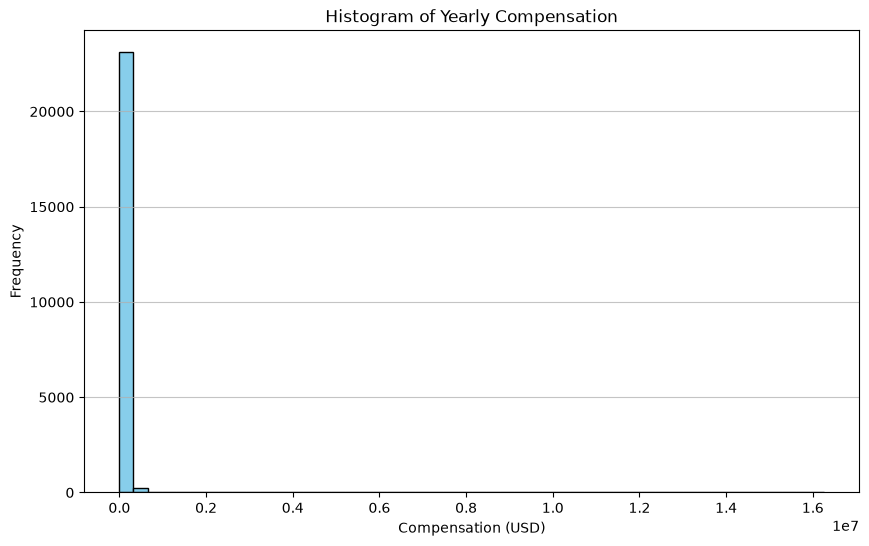

In [4]:
## Write your code here
# Plotting the histogram of ConvertedCompYearly
plt.figure(figsize=(10, 6))
plt.hist(df['ConvertedCompYearly'], bins=50, color='skyblue', edgecolor='black')
plt.title('Histogram of Yearly Compensation')
plt.xlabel('Compensation (USD)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

##### 2. Box Plot of `Age`


Since `Age` is categorical in the dataset, convert it to numerical values for a box plot.



In [8]:
# Check the first few rows and the data type
print(df['Age'].head())
print(df['Age'].unique())

0    Under 18 years old
1       35-44 years old
2       45-54 years old
3       18-24 years old
4       18-24 years old
Name: Age, dtype: str
<StringArray>
['Under 18 years old',    '35-44 years old',    '45-54 years old',
    '18-24 years old',    '25-34 years old',    '55-64 years old',
  'Prefer not to say',  '65 years or older']
Length: 8, dtype: str


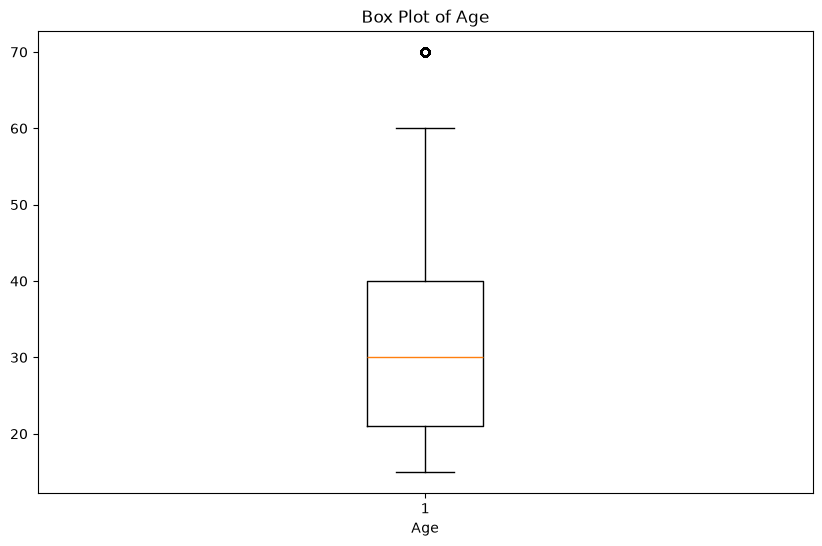

In [10]:
## Write your code here
# 1. Define a mapping dictionary to convert categories to representative numbers
age_map = {
    'Under 18 years old': 15,
    '18-24 years old': 21,
    '25-34 years old': 30,
    '35-44 years old': 40,
    '45-54 years old': 50,
    '55-64 years old': 60,
    '65 years or older': 70
}

# 2. Create the new numeric column by mapping the 'Age' column
df['Age_num'] = df['Age'].map(age_map)

# 3. Drop rows where no mapping was found (like 'Prefer not to say')
df_age_clean = df.dropna(subset=['Age_num'])

# 4. Create the box plot
plt.figure(figsize=(10, 6))
plt.boxplot(df_age_clean['Age_num'])
plt.title('Box Plot of Age')
plt.xlabel('Age')
plt.show()

### Task 2: Visualizing Relationships in Data


##### 1. Scatter Plot of `Age_numeric` and `ConvertedCompYearly`


Explore the relationship between age and compensation.



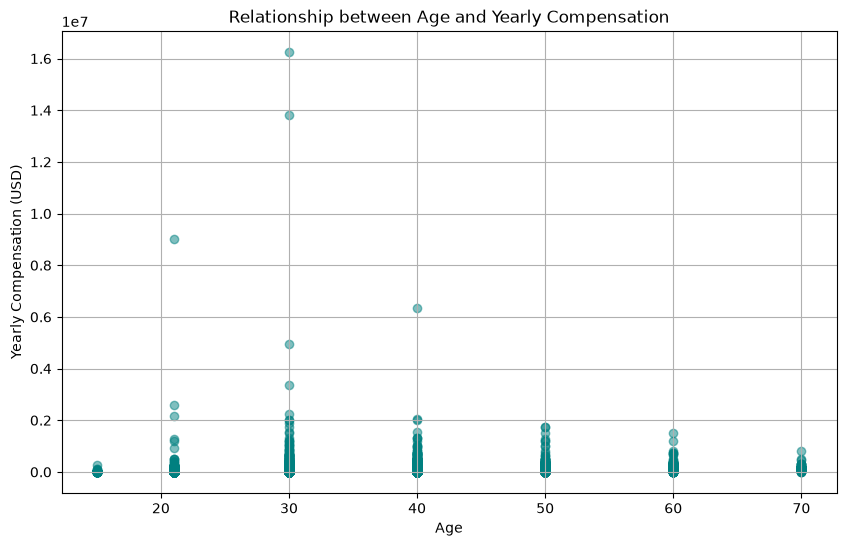

In [11]:
## Write your code here# 1. Create a scatter plot to explore the relationship
plt.figure(figsize=(10, 6))
plt.scatter(df['Age_num'], df['ConvertedCompYearly'], alpha=0.5, color='teal')

# 2. Add labels and title
plt.title('Relationship between Age and Yearly Compensation')
plt.xlabel('Age')
plt.ylabel('Yearly Compensation (USD)')
plt.grid(True)
plt.show()

##### 2. Bubble Plot of `ConvertedCompYearly` and `JobSatPoints_6` with `Age_numeric` as Bubble Size


Explore how compensation and job satisfaction are related, with age as the bubble size.


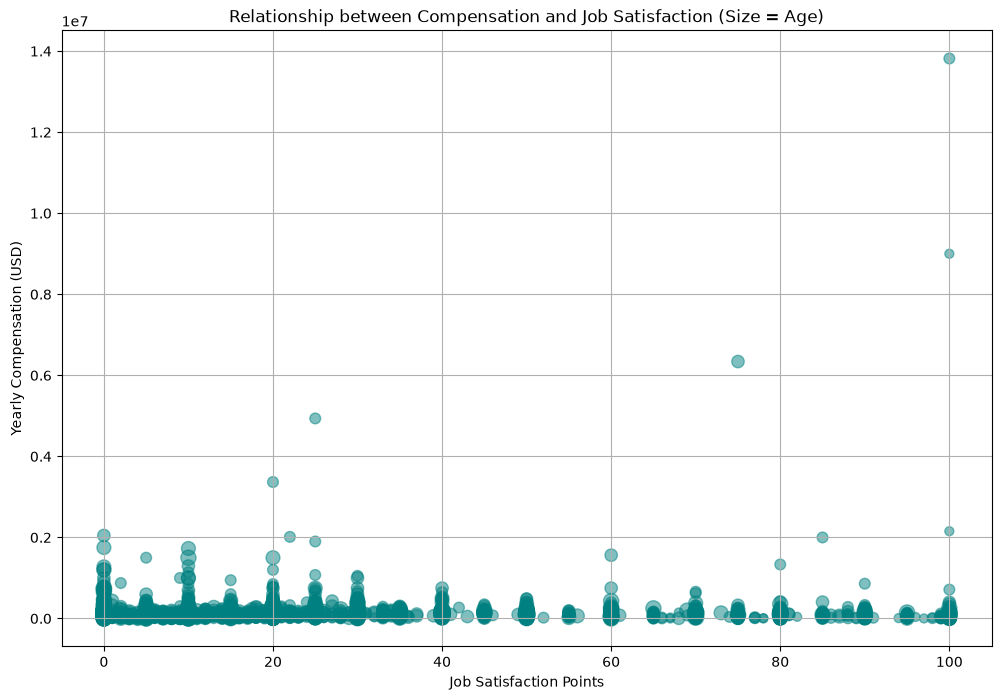

In [13]:
## Write your code here
# Create the bubble plot
plt.figure(figsize=(12, 8))

# We use 's' to set the size of the bubbles based on Age_num
# We multiply by a factor (e.g., 20) to make the bubbles visible
plt.scatter(df['JobSatPoints_6'], 
            df['ConvertedCompYearly'], 
            s=df['Age_num'] * 2, 
            alpha=0.5, 
            color='teal')

# Add labels and title
plt.title('Relationship between Compensation and Job Satisfaction (Size = Age)')
plt.xlabel('Job Satisfaction Points')
plt.ylabel('Yearly Compensation (USD)')
plt.grid(True)
plt.show()

### Task 3: Visualizing Composition of Data with Bar Charts


##### 1. Horizontal Bar Chart of `MainBranch` Distribution


Visualize the distribution of respondents’ primary roles to understand their professional focus.



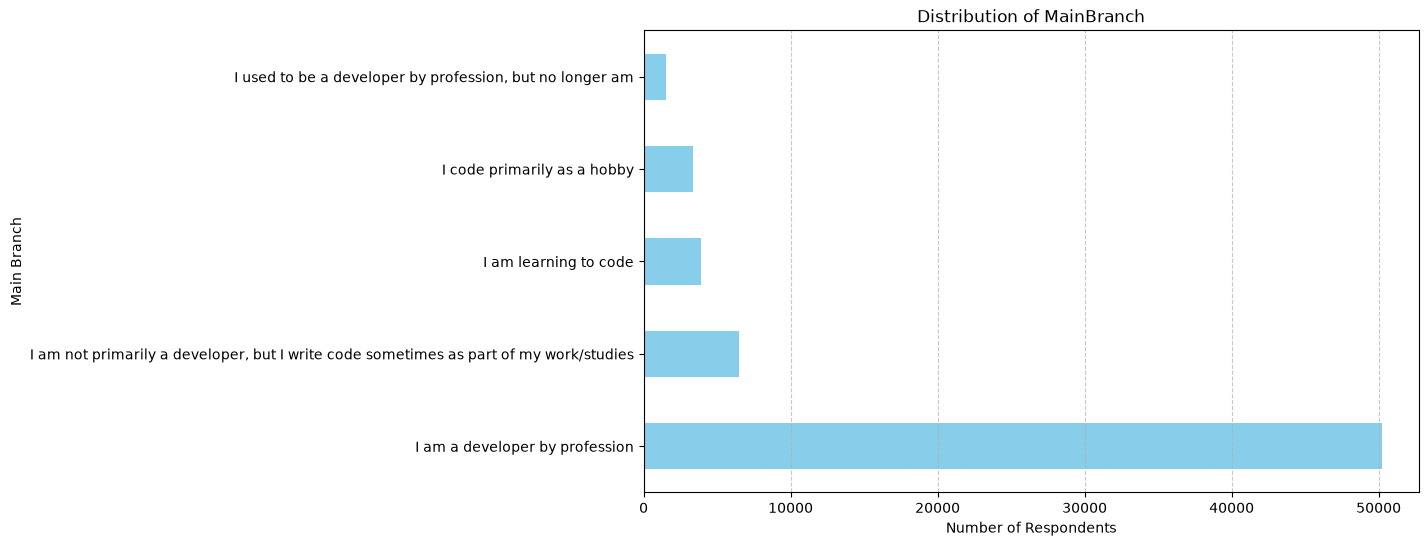

In [15]:
## Write your code here
## 1. Count the occurrences of each category in 'MainBranch'
branch_counts = df['MainBranch'].value_counts()

# 2. Create the horizontal bar chart
plt.figure(figsize=(10, 6))
branch_counts.plot(kind='barh', color='skyblue')

# 3. Add labels and title
plt.title('Distribution of MainBranch')
plt.xlabel('Number of Respondents')
plt.ylabel('Main Branch')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

##### 2. Vertical Bar Chart of Top 5 Programming Languages Respondents Want to Work With


Identify the most desired programming languages based on `LanguageWantToWorkWith`.



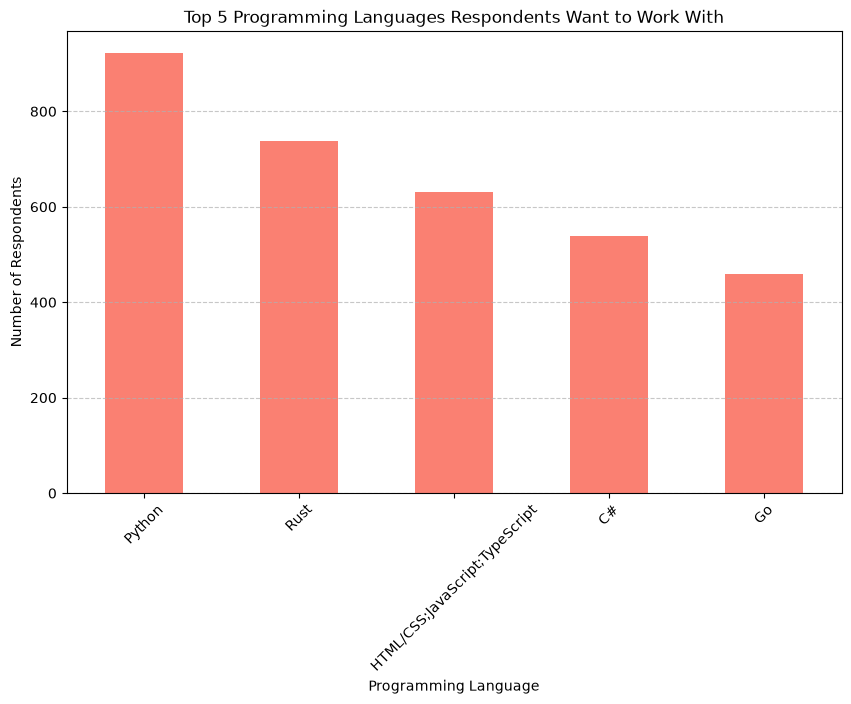

In [16]:
## Write your code here
# 1. Split the semicolons, explode into individual items, and count frequencies
# This converts the combined strings into a flat Series of individual languages
lang_counts = df['LanguageWantToWorkWith'].str.split('; ', expand=True).stack().value_counts()

# 2. Extract the top 5 most popular languages
top_5_langs = lang_counts.head(5)

# 3. Create the vertical bar chart
plt.figure(figsize=(10, 6))
top_5_langs.plot(kind='bar', color='salmon')

# 4. Add labels, title, and formatting for readability
plt.title('Top 5 Programming Languages Respondents Want to Work With')
plt.xlabel('Programming Language')
plt.ylabel('Number of Respondents')
plt.xticks(rotation=45) # Rotates labels to prevent overlap
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

##### 3. Stacked Bar Chart of Median `JobSatPoints_6` and `JobSatPoints_7` by Age Group


Compare job satisfaction metrics across different age groups with a stacked bar chart.


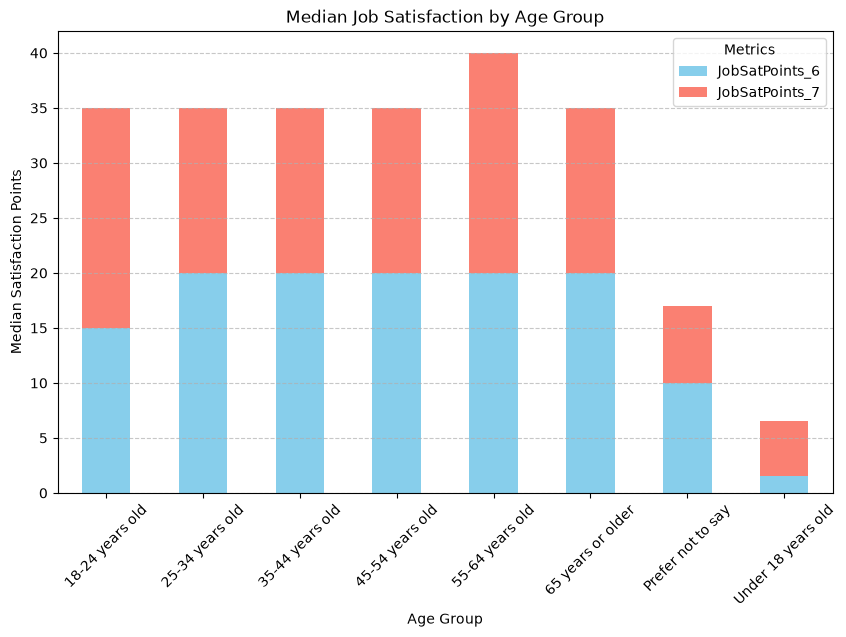

In [17]:
## Write your code here
# 1. Group by Age and calculate the median for the satisfaction columns
# Assuming 'JobSatPoints_6' and 'JobSatPoints_7' are the columns
df_grouped = df.groupby('Age')[['JobSatPoints_6', 'JobSatPoints_7']].median()

# 2. Plot as a stacked bar chart
df_grouped.plot(kind='bar', stacked=True, figsize=(10, 6), color=['skyblue', 'salmon'])

# 3. Add labels and title
plt.title('Median Job Satisfaction by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Median Satisfaction Points')
plt.xticks(rotation=45)
plt.legend(title='Metrics')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

##### 4. Bar Chart of Database Popularity (`DatabaseHaveWorkedWith`)


Identify the most commonly used databases among respondents by visualizing `DatabaseHaveWorkedWith`.



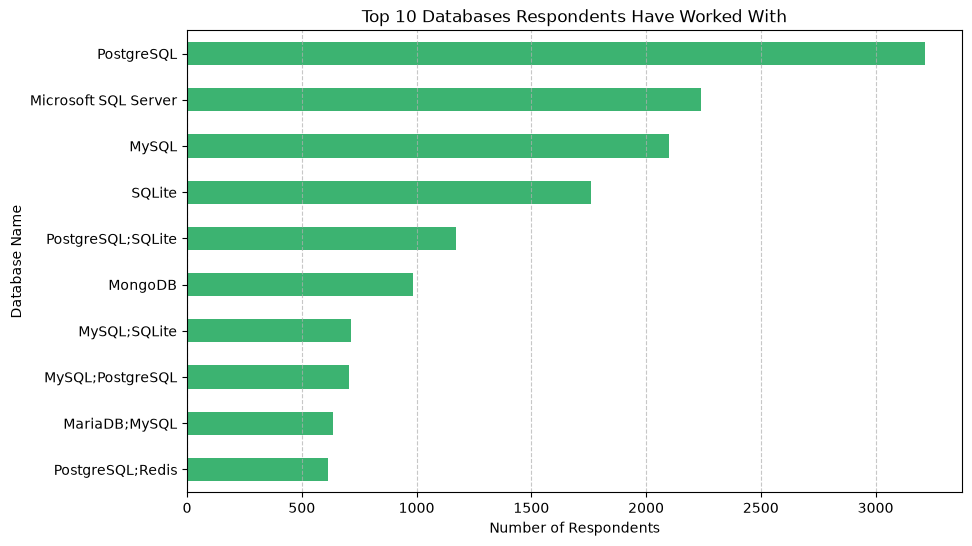

In [22]:
## Write your code here
# 1. Split, explode, count, AND take only the top 10
db_counts = df['DatabaseHaveWorkedWith'].str.split('; ', expand=True).stack().value_counts().head(10)

# 2. Setup the figure
fig, ax = plt.subplots(figsize=(10, 6))

# 3. Plot only the top 10
db_counts.plot(kind='barh', color='mediumseagreen', ax=ax)

# 4. Labels and formatting
ax.set_title('Top 10 Databases Respondents Have Worked With')
ax.set_xlabel('Number of Respondents')
ax.set_ylabel('Database Name')
ax.invert_yaxis()  # Puts the most popular database at the top
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.show()

### Task 4: Visualizing Comparison of Data with Bar Charts


##### 1. Grouped Bar Chart of Median `ConvertedCompYearly` for Different Age Groups


Compare median compensation across multiple age groups with a grouped bar chart.



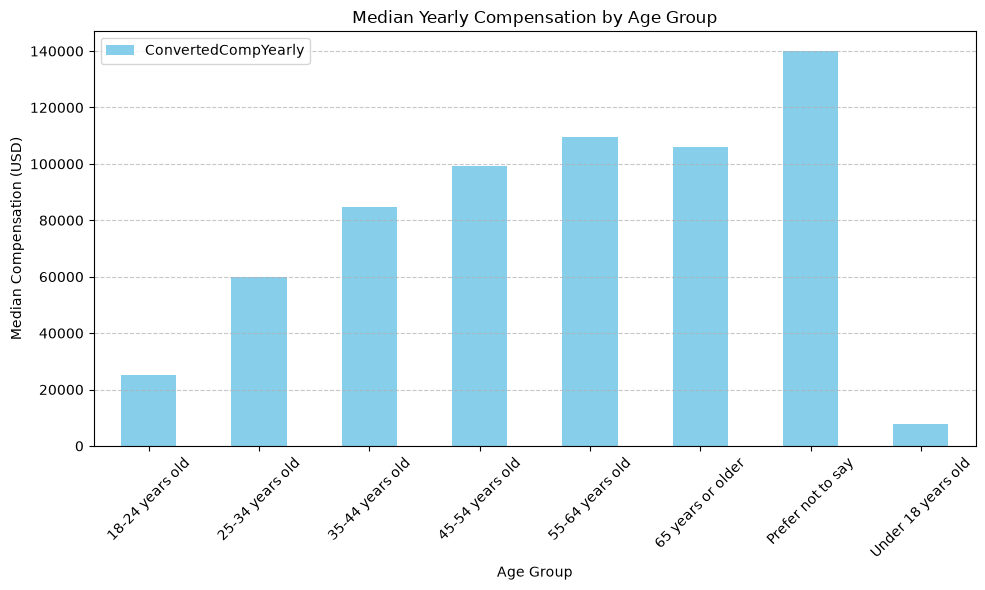

In [23]:
## Write your code here
# 1. Group by Age and calculate the median for ConvertedCompYearly
# We use .sort_index() to ensure age groups (if strings) display in logical order
df_grouped = df.groupby('Age')[['ConvertedCompYearly']].median().sort_index()

# 2. Create the grouped bar chart
plt.figure(figsize=(10, 6))
df_grouped.plot(kind='bar', color='skyblue', ax=plt.gca())

# 3. Add labels and title
plt.title('Median Yearly Compensation by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Median Compensation (USD)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout() # Ensures labels are not cut off
plt.show()

##### 2. Bar Chart of Respondent Count by Country


Show the distribution of respondents by country to see which regions are most represented.



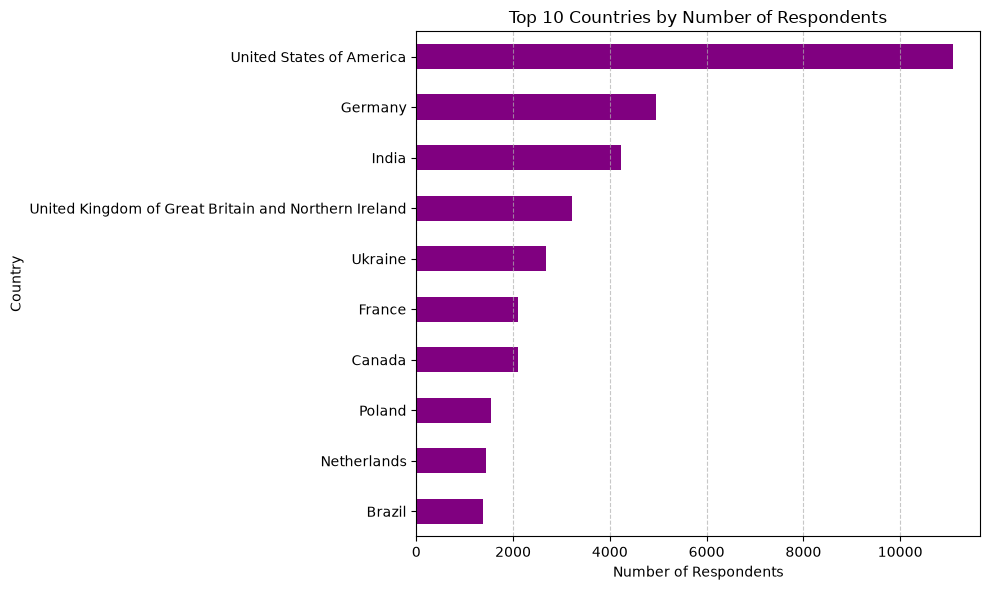

In [24]:
## Write your code here
# 1. Count the occurrences of each country
# We use .value_counts() to get the counts and .head(10) to limit to top 10
country_counts = df['Country'].value_counts().head(10)

# 2. Create the horizontal bar chart
plt.figure(figsize=(10, 6))
country_counts.plot(kind='barh', color='purple')

# 3. Add labels and title
plt.title('Top 10 Countries by Number of Respondents')
plt.xlabel('Number of Respondents')
plt.ylabel('Country')
plt.grid(axis='x', linestyle='--', alpha=0.7)

# 4. Invert y-axis so the most frequent country is at the top
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

### Final Step: Review


This lab demonstrates how to create and interpret different types of bar charts, allowing you to analyze the composition, comparison, and distribution of categorical data in the Stack Overflow dataset, including main professional branches, programming language preferences, and compensation by age group. Bar charts effectively compare counts and median values across various categories.


## Summary


After completing this lab, you will be able to:
- Create a horizontal bar chart to visualize the distribution of respondents' primary roles, helping to understand their professional focus.
- Develop a vertical bar chart to identify the most desired programming languages based on the LanguageWantToWorkWith variable.
- Use a stacked bar chart to compare job satisfaction metrics across different age groups.
- Create a bar chart to visualize the most commonly used databases among respondents using the DatabaseHaveWorkedWith variable.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
